In [79]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

In [80]:
mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["savefig.dpi"] = 300

font_size = 12
mpl.rcParams["font.size"] = font_size
mpl.rcParams["axes.titlesize"] = font_size
mpl.rcParams["axes.labelsize"] = font_size
mpl.rcParams["xtick.labelsize"] = font_size
mpl.rcParams["ytick.labelsize"] = font_size
mpl.rcParams["legend.fontsize"] = font_size
mpl.rcParams["figure.titlesize"] = font_size

# CE0

Data preprocessing

In [81]:
# import from "Results" of the validated models and implemented pydhn and pandapipes

base_path = Path.cwd()
results_path = base_path / "Results"

reference_0 = pd.read_csv(results_path / "destest_network_0_results.csv", sep=";")
pydhn_0 = pd.read_csv(results_path / "network_CE0_pydhn_results.csv", sep=";")
pandapipes_0 = pd.read_csv(results_path / "network_CE0_pandapipes_results.csv", sep=";")

In [82]:
df_0 = (
    reference_0
    .merge(pydhn_0, on="KPI")
    .merge(pandapipes_0, on="KPI")
)

df_0 = df_0.set_index("KPI")

In [83]:
exclude_models_from_reference = ["pydhn", "pandapipes"]

reference_df = df_0.drop(columns=exclude_models_from_reference, errors="ignore")
reference_mean = reference_df.mean(axis=1)

df_0["Reference"] = reference_mean

NMBE calculation

In [84]:
nmbe_df_0 = (
    df_0.drop(columns="Reference")
      .sub(reference_mean, axis=0)
      .div(reference_mean, axis=0)
      * 100
)

Plot

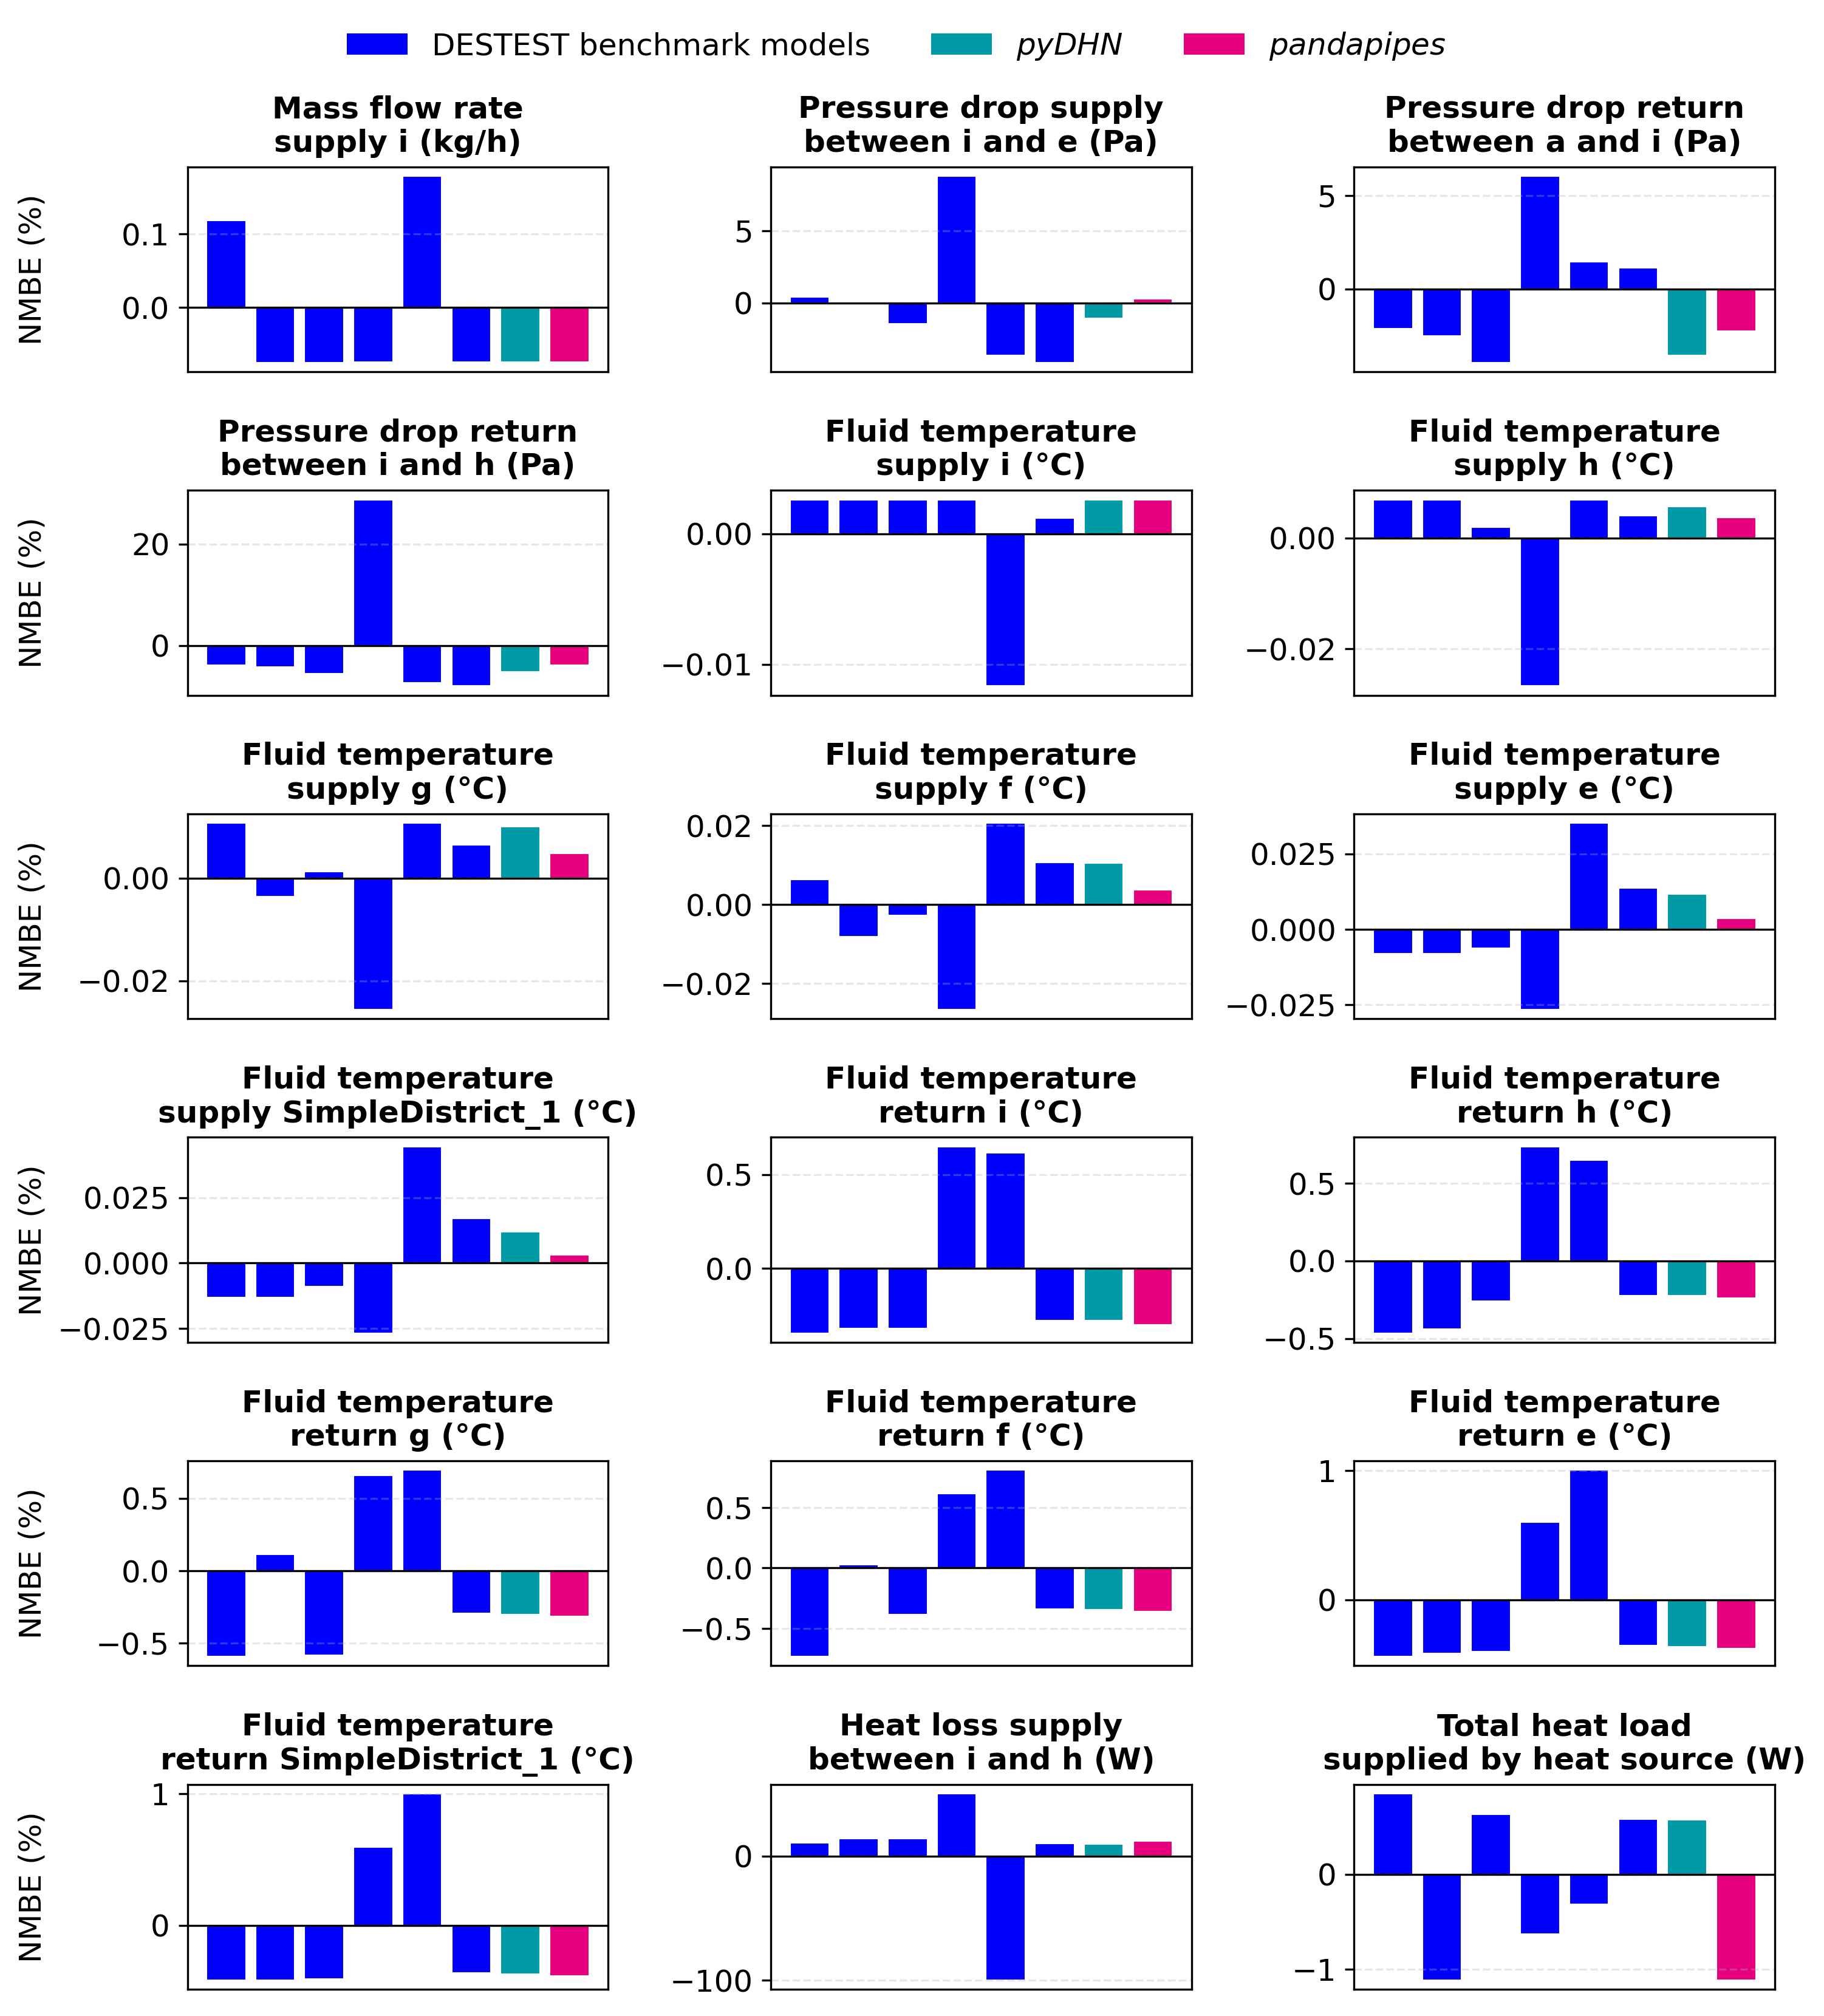

In [85]:
kpis_0 = df_0.index.tolist()

kpi_0_titles = [
    "Mass flow rate\nsupply i (kg/h)",
    "Pressure drop supply\nbetween i and e (Pa)",
    "Pressure drop return\nbetween a and i (Pa)",
    "Pressure drop return\nbetween i and h (Pa)",
    "Fluid temperature\nsupply i (°C)",
    "Fluid temperature\nsupply h (°C)",
    "Fluid temperature\nsupply g (°C)",
    "Fluid temperature\nsupply f (°C)",
    "Fluid temperature\nsupply e (°C)",
    "Fluid temperature\nsupply SimpleDistrict_1 (°C)",
    "Fluid temperature\nreturn i (°C)",
    "Fluid temperature\nreturn h (°C)",
    "Fluid temperature\nreturn g (°C)",
    "Fluid temperature\nreturn f (°C)",
    "Fluid temperature\nreturn e (°C)",
    "Fluid temperature\nreturn SimpleDistrict_1 (°C)",
    "Heat loss supply\nbetween i and h (W)",
    "Total heat load\nsupplied by heat source (W)",
]

colors = {
    "pydhn": "#009AA6",
    "pandapipes": "#e6007e",
}
validated_color = "blue"

n_kpi = len(kpis_0)
n_cols = 3
n_rows = int(np.ceil(n_kpi / n_cols))

width_inch = 10
height_per_row = 1.8

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(width_inch, height_per_row * n_rows),
    squeeze=False
)

for i, kpi in enumerate(kpis_0):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row][col]

    values = nmbe_df_0.loc[kpi]
    v_series = pd.Series(values.to_dict())

    bar_colors = [
        colors.get(model, validated_color)
        for model in v_series.index
    ]

    x = np.arange(len(v_series))

    ax.bar(
        x,
        v_series.values,
        color=bar_colors,
        alpha=1.0,
        edgecolor="white",
        linewidth=0.5
    )

    ax.set_xticks([])
    ax.set_title(kpi_0_titles[i], weight="bold")

    if col == 0:
        ax.set_ylabel("NMBE (%)")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols][j % n_cols])

fig.align_ylabels(axes)

legend_elements = [
    Patch(facecolor=validated_color, label="DESTEST benchmark models"),
    Patch(facecolor=colors["pydhn"], label=r'$\mathit{pyDHN}$'),
    Patch(facecolor=colors["pandapipes"], label=r'$\mathit{pandapipes}$')
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 1])

plt.savefig(
    results_path / "results_network_0.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()